# Guide to load dataset for inference


## LeRobot Format

* This tutorial will show how to load data in LeRobot Format by using our dataloader. 
* We will use the `robot_sim.PickNPlace` dataset as an example which is already converted to LeRobot Format. 
* To understand how to convert your own dataset, please refer to [Gr00t's LeRobot.md](LeRobot_compatible_data_schema.md)

In [1]:
from gr00t.utils.misc import any_describe
from gr00t.data.dataset import LeRobotSingleDataset
from gr00t.data.dataset import ModalityConfig
from gr00t.data.schema import EmbodimentTag

/data/shrelic/conda/envs/gr00t/lib/python3.10/site-packages/albumentations/__init__.py:13: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.18). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


## Loading the dataset

We need to define 3 things to load the dataset:
1. Path to the dataset

2. `ModalityConfigs`

- `ModalityConfigs` defines what data modalities (like video, state, actions, language) to use downstream like model training or inference.
- Each modality specifies which frame to load via delta_indices (e.g. [0] means current frame only, [-1,0] means previous and current frame)

3. `EmbodimentTag`
- `EmbodimentTag` is used to specify the embodiment of the dataset. A list of all the embodiment tags can be found in `gr00t.data.embodiment_tags.EmbodimentTag`.
- GR00T's architecture has different action heads optimized for specific robot types (embodiments). `EmbodimentTag` tells the model which action head to use for fine-tuning and/or inference. In our case, since we're using a humanoid arm, we specify `EmbodimentTag.GR1_UNIFIED` to get the best performance from the humanoid-specific action head.


In [2]:

import os
import gr00t

# REPO_PATH is the path of the pip install gr00t repo and one level up
REPO_PATH = os.path.dirname(os.path.dirname(gr00t.__file__))
DATA_PATH = os.path.join(REPO_PATH, "demo_data/UAVFlowLeRobot")

print("Loading dataset... from", DATA_PATH)

Loading dataset... from /data/shrelic/other/Isaac-GR00T/demo_data/UAVFlowLeRobot


In [3]:
# 2. modality configs
modality_configs = {
    "video": ModalityConfig(
        delta_indices=[0],
        modality_keys=["video.ego_view"],
    ),
    "state": ModalityConfig(
        delta_indices=[0],
        modality_keys=[
            "state.drone",
        ],
    ),
    "action": ModalityConfig(
        delta_indices=[0],
        modality_keys=[
            "action.delta_pose",
        ],
    ),
    "language": ModalityConfig(
        delta_indices=[0],
        modality_keys=["annotation.human.action.task_description"],
    ),
}

In [6]:
# 3. gr00t embodiment tag
embodiment_tag = EmbodimentTag.NEW_EMBODIMENT

# load the dataset
dataset = LeRobotSingleDataset(DATA_PATH, modality_configs,  embodiment_tag=embodiment_tag, video_backend='torchvision_av')

print('\n'*2)
print("="*100)
print(f"{' Humanoid Dataset ':=^100}")
print("="*100)

# print the 7th data point
resp = dataset[0]
any_describe(resp)
print("--------------------------------------------------------")
print(resp.keys())
print("--------------------------------------------------------")
print(type(resp))

Initialized dataset UAVFlowLeRobot with EmbodimentTag.NEW_EMBODIMENT



========================================= Humanoid Dataset =========================================
getting video from /data/shrelic/other/Isaac-GR00T/demo_data/UAVFlowLeRobot/videos/chunk-000/video.ego_view/episode_000000.mp4,  timestamp: [0.] kwargs: {}
{'action.delta_pose': 'np: [1, 4] float64',
 'annotation.human.action.task_description': ['Travel past the tree from the '
                                              'right side'],
 'state.drone': 'np scalar: 0.0 [1, 1] float64',
 'video.ego_view': 'np: [1, 256, 256, 3] uint8'}
--------------------------------------------------------
dict_keys(['video.ego_view', 'state.drone', 'action.delta_pose', 'annotation.human.action.task_description'])
--------------------------------------------------------
<class 'dict'>


In [12]:
# Quick fix: switch dataset video backend to torchvision_av (PyAV) and retry one sample
import numpy as np

dataset.video_backend = "torchvision_av"
print("Switched video backend to:", dataset.video_backend)
resp_fix = dataset[0]
print("Keys:", resp_fix.keys())
print("ego_view shape:", resp_fix["video.ego_view"].shape)


Switched video backend to: torchvision_av
getting video from /data/shrelic/other/Isaac-GR00T/demo_data/UAVFlowLeRobot/videos/chunk-000/video.ego_view/episode_000000.mp4,  timestamp: [0.]
Keys: dict_keys(['video.ego_view', 'state.drone', 'action.delta_pose', 'annotation.human.action.task_description'])
ego_view shape: (1, 256, 256, 3)


In [10]:
# Debug get_frames_by_timestamps failure at t=0.0
import os, numpy as np, cv2, decord
from gr00t.utils.video import get_frames_by_timestamps

# 1) Build video path and timestamps from the current dataset
try:
    vp = dataset.get_video_path(trajectory_id=0, key="ego_view")  # key without "video."
    ts = np.array([0.0], dtype=np.float32)
    print("Video path:", vp)
    print("Exists:", os.path.exists(vp))
    if os.path.exists(vp):
        print("File size:", os.path.getsize(vp), "bytes")
except Exception as e:
    print("Failed to get video path:", e)

# 2) Try decord path with introspection
try:
    print("\n[Decord] trying to read...")
    vr = decord.VideoReader(str(vp))
    n = len(vr)
    print("Decord num_frames:", n)
    if n == 0:
        print("[Issue] Video has zero frames according to decord.")
    else:
        fts = vr.get_frame_timestamp(range(min(10, n)))
        print("First timestamps (start,end) from decord:")
        print(fts)
        # Map timestamp 0.0 to an index explicitly
        idx = np.abs(fts[:, :1] - ts).argmin(axis=0)
        print("Closest frame index for 0.0:", idx)
        frames = vr.get_batch(idx)
        arr = frames.asnumpy()
        print("Decord frame shape:", arr.shape, arr.dtype)
except Exception as e:
    print("[Decord] Exception:", repr(e))

# 3) Try OpenCV fallback quickly
try:
    print("\n[OpenCV] trying to read...")
    cap = cv2.VideoCapture(str(vp))
    if not cap.isOpened():
        print("OpenCV failed to open video")
    else:
        fps = cap.get(cv2.CAP_PROP_FPS)
        count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        print("OpenCV FPS:", fps, "Frame Count:", count)
        if fps <= 0 or count <= 0:
            print("[Issue] Invalid FPS or frame count in OpenCV metadata.")
        else:
            frame_ts = np.arange(count) / fps
            idx = int(np.abs(frame_ts - ts[0]).argmin())
            cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
            ok, fr = cap.read()
            print("OpenCV read ok:", ok, "shape:" if ok else "", fr.shape if ok else "")
    cap.release()
except Exception as e:
    print("[OpenCV] Exception:", repr(e))

# 4) Call our utility with both backends to compare
try:
    out_dec = get_frames_by_timestamps(str(vp), ts, video_backend="decord")
    print("util[decord] ->", out_dec.shape, out_dec.dtype)
except Exception as e:
    print("util[decord] Exception:", repr(e))

try:
    out_cv = get_frames_by_timestamps(str(vp), ts, video_backend="opencv")
    print("util[opencv] ->", out_cv.shape, out_cv.dtype)
except Exception as e:
    print("util[opencv] Exception:", repr(e))

Video path: /data/shrelic/other/Isaac-GR00T/demo_data/UAVFlowLeRobot/videos/chunk-000/video.ego_view/episode_000000.mp4
Exists: True
File size: 1723154 bytes

[Decord] trying to read...
[Decord] Exception: DECORDError('[22:45:44] /github/workspace/src/video/video_reader.cc:151: Check failed: st_nb >= 0 (-1128613112 vs. 0) ERROR cannot find video stream with wanted index: -1')

[OpenCV] trying to read...
OpenCV FPS: 5.0 Frame Count: 78
OpenCV read ok: False  
util[decord] Exception: DECORDError('[22:45:44] /github/workspace/src/video/video_reader.cc:151: Check failed: st_nb >= 0 (-1128613112 vs. 0) ERROR cannot find video stream with wanted index: -1')
util[opencv] Exception: ValueError('Unable to read frame at index 0')


[av1 @ 0x55e5e8660680] Your platform doesn't suppport hardware accelerated AV1 decoding.
[av1 @ 0x55e5e8660680] Failed to get pixel format.
[av1 @ 0x55e5e8660680] Missing Sequence Header.
[av1 @ 0x55e5e8660680] Your platform doesn't suppport hardware accelerated AV1 decoding.
[av1 @ 0x55e5e8660680] Failed to get pixel format.
[av1 @ 0x55e5e8660680] Missing Sequence Header.
[av1 @ 0x55e5e8660680] Your platform doesn't suppport hardware accelerated AV1 decoding.
[av1 @ 0x55e5e8660680] Failed to get pixel format.
[av1 @ 0x55e5e8660680] Missing Sequence Header.
[av1 @ 0x55e5e8660680] Your platform doesn't suppport hardware accelerated AV1 decoding.
[av1 @ 0x55e5e8660680] Failed to get pixel format.
[av1 @ 0x55e5e8660680] Missing Sequence Header.
[av1 @ 0x55e5e8660680] Your platform doesn't suppport hardware accelerated AV1 decoding.
[av1 @ 0x55e5e8660680] Failed to get pixel format.
[av1 @ 0x55e5e8660680] Missing Sequence Header.
[av1 @ 0x55e5e8660680] Your platform doesn't suppport hardwa

In [5]:
dataset[1]

NameError: name 'dataset' is not defined

Show Image frames within the data


getting video from /data/shrelic/other/Isaac-GR00T/demo_data/UAVFlowLeRobot/videos/chunk-000/video.ego_view/episode_000000.mp4,  timestamp: [0.] kwargs: {}
getting video from /data/shrelic/other/Isaac-GR00T/demo_data/UAVFlowLeRobot/videos/chunk-000/video.ego_view/episode_000000.mp4,  timestamp: [2.] kwargs: {}
getting video from /data/shrelic/other/Isaac-GR00T/demo_data/UAVFlowLeRobot/videos/chunk-000/video.ego_view/episode_000000.mp4,  timestamp: [4.] kwargs: {}
getting video from /data/shrelic/other/Isaac-GR00T/demo_data/UAVFlowLeRobot/videos/chunk-000/video.ego_view/episode_000000.mp4,  timestamp: [6.] kwargs: {}
getting video from /data/shrelic/other/Isaac-GR00T/demo_data/UAVFlowLeRobot/videos/chunk-000/video.ego_view/episode_000000.mp4,  timestamp: [8.] kwargs: {}
getting video from /data/shrelic/other/Isaac-GR00T/demo_data/UAVFlowLeRobot/videos/chunk-000/video.ego_view/episode_000000.mp4,  timestamp: [10.] kwargs: {}
getting video from /data/shrelic/other/Isaac-GR00T/demo_data/UA

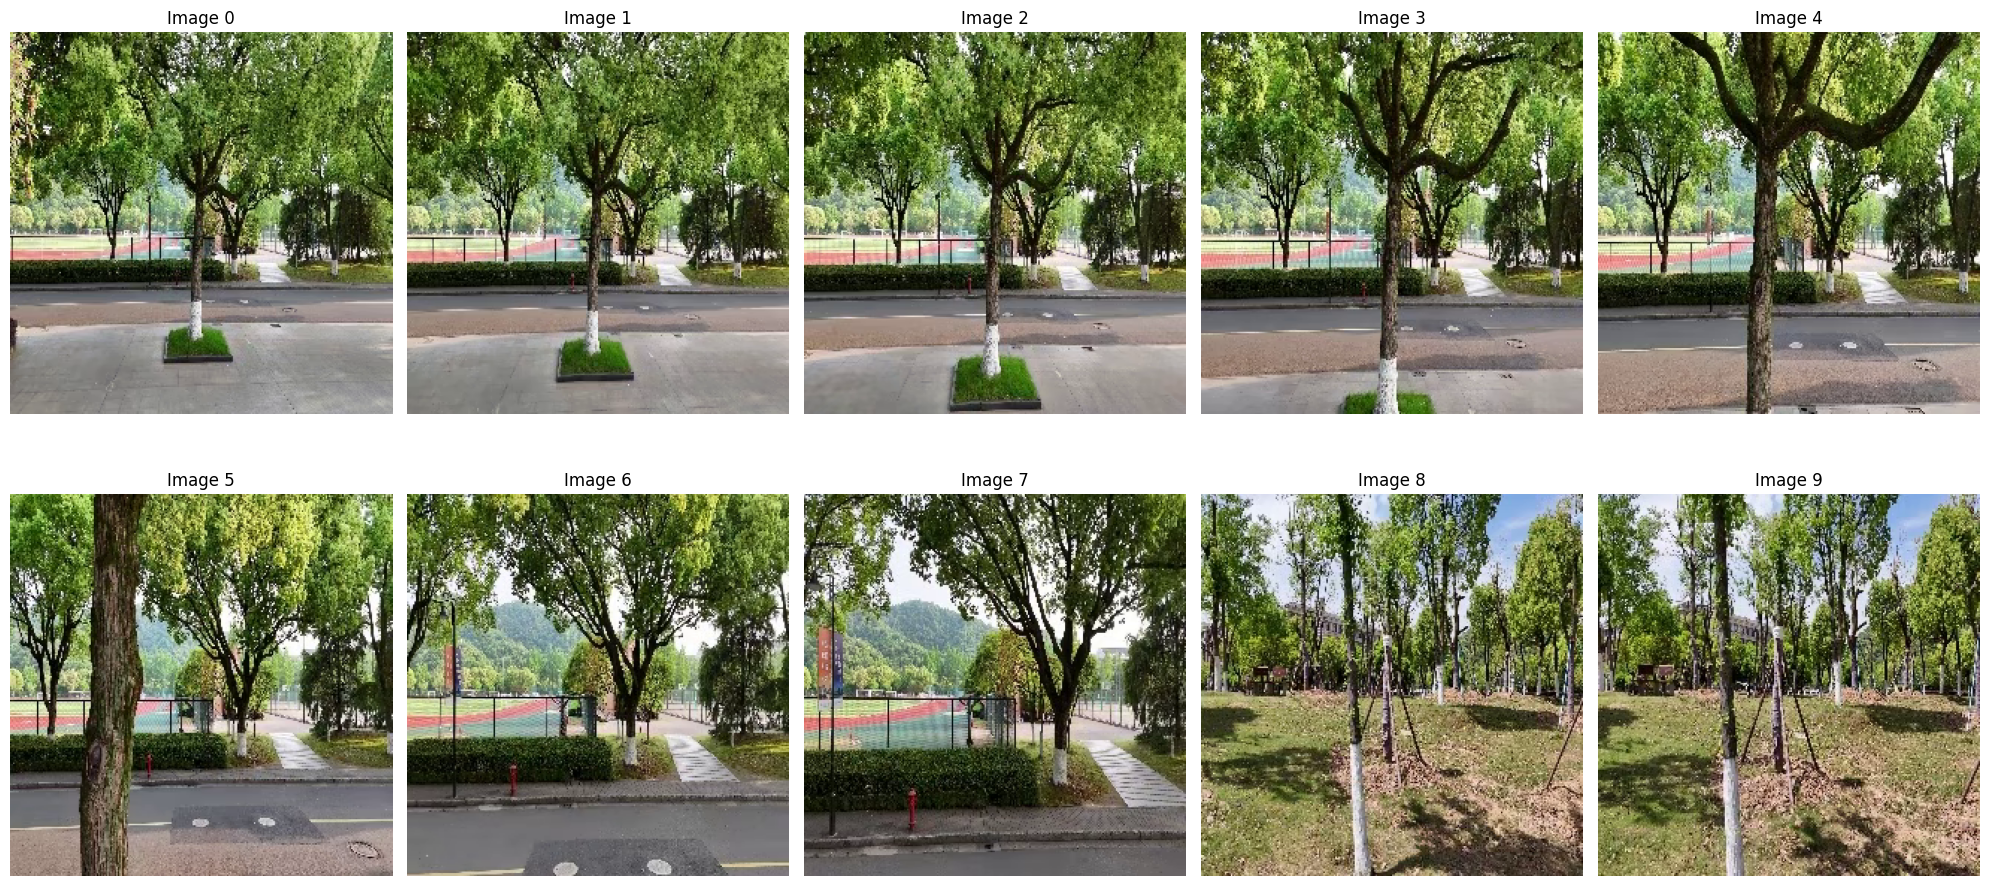

In [7]:
# show img
import matplotlib.pyplot as plt

images_list = []

for i in range(100):
    if i % 10 == 0:
        resp = dataset[i]
        img = resp["video.ego_view"][0]
        images_list.append(img)


fig, axs = plt.subplots(2, 5, figsize=(20, 10))
for i, ax in enumerate(axs.flat):
    ax.imshow(images_list[i])
    ax.axis("off")
    ax.set_title(f"Image {i}")
plt.tight_layout() # adjust the subplots to fit into the figure area.
plt.show()


## Transforming the data

We can also apply a series of transformation to the data to our `LeRobotSingleDataset` class. This shows how to apply transformations to the data.

In [6]:
from gr00t.data.transform.base import ComposedModalityTransform
from gr00t.data.transform import VideoToTensor, VideoCrop, VideoResize, VideoColorJitter, VideoToNumpy
from gr00t.data.transform.state_action import StateActionToTensor, StateActionTransform
from gr00t.data.transform.concat import ConcatTransform


video_modality = modality_configs["video"]
state_modality = modality_configs["state"]
action_modality = modality_configs["action"]

# select the transforms you want to apply to the data
to_apply_transforms = ComposedModalityTransform(
    transforms=[
        # video transforms
        VideoToTensor(apply_to=video_modality.modality_keys),
        VideoCrop(apply_to=video_modality.modality_keys, scale=0.95),
        VideoResize(apply_to=video_modality.modality_keys, height=224, width=224, interpolation="linear"),
        VideoColorJitter(apply_to=video_modality.modality_keys, brightness=0.3, contrast=0.4, saturation=0.5, hue=0.08),
        VideoToNumpy(apply_to=video_modality.modality_keys),

        # state transforms
        StateActionToTensor(apply_to=state_modality.modality_keys),
        StateActionTransform(apply_to=state_modality.modality_keys, normalization_modes={
            key: "min_max" for key in state_modality.modality_keys
        }),

        # action transforms
        StateActionToTensor(apply_to=action_modality.modality_keys),
        StateActionTransform(apply_to=action_modality.modality_keys, normalization_modes={
            key: "min_max" for key in action_modality.modality_keys
        }),

        # ConcatTransform
        ConcatTransform(
            video_concat_order=video_modality.modality_keys,
            state_concat_order=state_modality.modality_keys,
            action_concat_order=action_modality.modality_keys,
        ),
    ]
)

Now see how the data is different after applying the transformations.

e.g. states and actions are being normalized and concatenated, video images are being cropped, resized, and color-jittered.

In [7]:
dataset = LeRobotSingleDataset(
    DATA_PATH,
    modality_configs,
    transforms=to_apply_transforms,
    embodiment_tag=embodiment_tag
)

# print the 7th data point
resp = dataset[7]
any_describe(resp)
print(resp.keys())


Initialized dataset robot_sim.PickNPlace with EmbodimentTag.GR1
{'action': 'torch: [1, 12] torch.float64 cpu',
 'annotation.human.action.task_description': ['pick the pear from the counter '
                                              'and place it in the plate'],
 'annotation.human.validity': ['valid'],
 'state': 'torch: [1, 44] torch.float64 cpu',
 'video': 'np: [1, 1, 224, 224, 3] uint8'}
dict_keys(['annotation.human.action.task_description', 'annotation.human.validity', 'video', 'state', 'action'])


总的来说，看起来一个episode对应一段video，每个episode为一个trajectory，按照fps来采样可以采样出length个样本点（length = fps * t），每个样本点都可以得到对应的frame（从video中通过timestamp得到）、action、state（从parquet中得到）. 这些样本点都依据(trajectory, index)来检索，其中index为0, 1, 2, ... ,length-1

## Delta Indices 深入理解

`delta_indices` 是LeRobot数据加载器中的一个核心概念，它定义了**相对于当前时间步要读取哪些历史或未来的数据帧**。

### 基本概念

- `delta_indices = [0]`: 只读取当前帧
- `delta_indices = [-1, 0]`: 读取前一帧和当前帧  
- `delta_indices = [-2, -1, 0]`: 读取前两帧、前一帧和当前帧
- `delta_indices = [0, 1]`: 读取当前帧和下一帧

这对于需要**时序信息**的机器人学习任务非常重要，比如：
- 动作预测需要历史状态信息
- 视觉SLAM需要连续帧进行运动估计
- 强化学习中策略可能依赖于状态变化趋势

In [9]:
# 演示不同delta_indices的效果

print("=== Delta Indices 演示 ===\n")

# 示例1: 只读取当前帧 [0]
modality_config_current = {
    "video": ModalityConfig(
        delta_indices=[0],  # 只要当前帧
        modality_keys=["video.ego_view"],
    ),
    "state": ModalityConfig(
        delta_indices=[0],
        modality_keys=["state.left_arm"],
    ),
}

dataset_current = LeRobotSingleDataset(DATA_PATH, modality_config_current, embodiment_tag=embodiment_tag)

# 示例2: 读取前一帧和当前帧 [-1, 0] 
modality_config_history = {
    "video": ModalityConfig(
        delta_indices=[-1, 0],  # 前一帧 + 当前帧
        modality_keys=["video.ego_view"],
    ),
    "state": ModalityConfig(
        delta_indices=[-1, 0],
        modality_keys=["state.left_arm"],
    ),
}

dataset_history = LeRobotSingleDataset(DATA_PATH, modality_config_history, embodiment_tag=embodiment_tag)

# 示例3: 读取更多历史帧 [-3, -2, -1, 0]
modality_config_multi_history = {
    "video": ModalityConfig(
        delta_indices=[-3, -2, -1, 0],  # 4帧历史
        modality_keys=["video.ego_view"],
    ),
    "state": ModalityConfig(
        delta_indices=[-3, -2, -1, 0],
        modality_keys=["state.left_arm"],
    ),
}

=== Delta Indices 演示 ===

Initialized dataset robot_sim.PickNPlace with EmbodimentTag.GR1
Initialized dataset robot_sim.PickNPlace with EmbodimentTag.GR1


In [10]:
dataset_multi_history = LeRobotSingleDataset(DATA_PATH, modality_config_multi_history, embodiment_tag=embodiment_tag)

# 比较不同配置下的数据形状
print("1. 只读取当前帧 delta_indices=[0]:")
resp1 = dataset_current[10]
print(f"   Video shape: {resp1['video.ego_view'].shape}")  # 应该是 (1, H, W, C)
print(f"   State shape: {resp1['state.left_arm'].shape}")  # 应该是 (1, 7)

print("\n2. 读取前一帧+当前帧 delta_indices=[-1, 0]:")
resp2 = dataset_history[10] 
print(f"   Video shape: {resp2['video.ego_view'].shape}")  # 应该是 (2, H, W, C)
print(f"   State shape: {resp2['state.left_arm'].shape}")  # 应该是 (2, 7)

print("\n3. 读取4帧历史 delta_indices=[-3, -2, -1, 0]:")
resp3 = dataset_multi_history[10]
print(f"   Video shape: {resp3['video.ego_view'].shape}")  # 应该是 (4, H, W, C) 
print(f"   State shape: {resp3['state.left_arm'].shape}")  # 应该是 (4, 7)

print("\n=== 数据形状解释 ===")
print("第一个维度就是时间维度T，对应delta_indices的长度")
print("- delta_indices=[0] -> T=1 (只有当前帧)")  
print("- delta_indices=[-1,0] -> T=2 (前一帧+当前帧)")
print("- delta_indices=[-3,-2,-1,0] -> T=4 (4个时间步)")

Initialized dataset robot_sim.PickNPlace with EmbodimentTag.GR1
1. 只读取当前帧 delta_indices=[0]:
   Video shape: (1, 256, 256, 3)
   State shape: (1, 7)

2. 读取前一帧+当前帧 delta_indices=[-1, 0]:
   Video shape: (2, 256, 256, 3)
   State shape: (2, 7)

3. 读取4帧历史 delta_indices=[-3, -2, -1, 0]:
   Video shape: (4, 256, 256, 3)
   State shape: (4, 7)

=== 数据形状解释 ===
第一个维度就是时间维度T，对应delta_indices的长度
- delta_indices=[0] -> T=1 (只有当前帧)
- delta_indices=[-1,0] -> T=2 (前一帧+当前帧)
- delta_indices=[-3,-2,-1,0] -> T=4 (4个时间步)


### 边界情况处理

当`delta_indices`包含负数时，在trajectory开始位置可能会访问不存在的帧。LeRobot通过**padding策略**处理这种情况：

- **绝对数据**（如关节位置）：用第一帧/最后一帧数据填充
- **相对数据**（如关节速度）：用0填充

让我们看看边界情况的处理：

In [13]:
# 演示边界情况处理
import numpy as np

print("=== 边界情况处理演示 ===\n")

# 在trajectory开始位置读取历史数据
print("在trajectory开始位置（index=0）读取历史数据:")
resp_start = dataset_history[0]  # 第一个样本，但要读取[-1, 0]
print(f"Video shape: {resp_start['video.ego_view'].shape}")
print(f"State shape: {resp_start['state.left_arm'].shape}")

# 检查是否正确padding
print("\n检查padding效果 (前一帧应该等于当前帧，因为padding用第一帧填充):")
video_data = resp_start['video.ego_view']
state_data = resp_start['state.left_arm']

print(f"视频帧是否相同: {np.allclose(video_data[0], video_data[1])}")
print(f"状态数据是否相同: {np.allclose(state_data[0], state_data[1])}")

print(f"\n前一帧状态值: {state_data[0][:3]}")  # 只显示前3个值
print(f"当前帧状态值: {state_data[1][:3]}")    # 只显示前3个值

=== 边界情况处理演示 ===

在trajectory开始位置（index=0）读取历史数据:
Video shape: (2, 256, 256, 3)
State shape: (2, 7)

检查padding效果 (前一帧应该等于当前帧，因为padding用第一帧填充):
视频帧是否相同: True
状态数据是否相同: True

前一帧状态值: [-0.01147083  0.12207967  0.04229397]
当前帧状态值: [-0.01147083  0.12207967  0.04229397]


### 实际应用场景

`delta_indices`在不同的机器人学习任务中有不同的用途：

#### 1. **Vision-Based Control (视觉控制)**
```python
# 使用连续帧检测运动
modality_config = {
    "video": ModalityConfig(
        delta_indices=[-2, -1, 0],  # 3帧连续视觉输入
        modality_keys=["video.ego_view"],
    )
}
```

#### 2. **Action Prediction (动作预测)**  
```python
# 基于历史状态预测未来动作
modality_config = {
    "state": ModalityConfig(
        delta_indices=[-4, -3, -2, -1, 0],  # 5步历史状态
        modality_keys=["state.left_arm", "state.right_arm"],
    ),
    "action": ModalityConfig(
        delta_indices=[1, 2, 3],  # 预测未来3步动作
        modality_keys=["action.left_arm", "action.right_arm"], 
    )
}
```

#### 3. **Temporal Modeling (时序建模)**
```python  
# 捕获长期依赖关系
modality_config = {
    "video": ModalityConfig(
        delta_indices=[-10, -5, -1, 0],  # 稀疏采样历史帧
        modality_keys=["video.ego_view"],
    )
}
```

### 总结

`delta_indices`是LeRobot中实现**时序数据访问**的核心机制：

- **时间轴控制**: 精确控制读取哪些时间步的数据
- **灵活配置**: 支持历史、当前、未来数据的任意组合  
- **自动padding**: 智能处理边界情况
- **多模态支持**: 不同模态可以有不同的时序配置

这使得同一个数据集可以灵活适应不同的学习任务需求，无需重新处理数据。

In [11]:
# Try torchvision_av (PyAV) backend explicitly
import numpy as np
from gr00t.utils.video import get_frames_by_timestamps, get_all_frames
import torchvision

try:
    vp = dataset.get_video_path(trajectory_id=0, key="ego_view")
    ts = np.array([0.0, 0.2, 0.4], dtype=np.float32)
    print("Using torchvision_av backend on:", vp)
    frames_ts = get_frames_by_timestamps(str(vp), ts, video_backend="torchvision_av")
    print("torchvision_av frames by ts:", frames_ts.shape, frames_ts.dtype)
    all_frames = get_all_frames(str(vp), video_backend="torchvision_av")
    print("torchvision_av all frames:", all_frames.shape, all_frames.dtype)
except Exception as e:
    print("[torchvision_av] Exception:", repr(e))

Using torchvision_av backend on: /data/shrelic/other/Isaac-GR00T/demo_data/UAVFlowLeRobot/videos/chunk-000/video.ego_view/episode_000000.mp4
torchvision_av frames by ts: (3, 256, 256, 3) uint8
torchvision_av all frames: (78, 256, 256, 3) uint8


In [13]:
# Inspect codec/pixel format with PyAV
import av

vp = dataset.get_video_path(trajectory_id=0, key="ego_view")
print("PyAV inspecting:", vp)

try:
    container = av.open(str(vp))
    stream_info = []
    for s in container.streams:
        if s.type == "video":
            info = {
                "type": s.type,
                "codec_name": getattr(s.codec_context, "name", None),
                "pix_fmt": getattr(s.codec_context, "format", None),
                "width": s.codec_context.width,
                "height": s.codec_context.height,
                "time_base": str(s.time_base),
                "avg_rate": str(s.average_rate) if s.average_rate else None,
                "frames": s.frames if s.frames else None,
            }
            stream_info.append(info)
    print("Video streams:")
    for i, info in enumerate(stream_info):
        print(f"  [{i}]", info)
except Exception as e:
    print("PyAV inspect exception:", repr(e))

PyAV inspecting: /data/shrelic/other/Isaac-GR00T/demo_data/UAVFlowLeRobot/videos/chunk-000/video.ego_view/episode_000000.mp4
Video streams:
  [0] {'type': 'video', 'codec_name': 'libdav1d', 'pix_fmt': <av.VideoFormat yuv420p, 256x256>, 'width': 256, 'height': 256, 'time_base': '1/10240', 'avg_rate': '5', 'frames': 78}
